In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
from collections import defaultdict
from pathlib import Path

import tempfile
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm

tqdm.pandas()

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.peint import EncodedPEINTDataset
from peint.models.modules.peint_module import PEINTModule
from evo.dataset import ComplexCherriesDataset
from evo.sequence import get_mutant, _AA_STR_SORTED
from evo.dms import get_site_by_site_consensus

In [44]:
# load the model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/logs/train/runs")
# ckpt_path = ckpt_dir / "2025-10-02_00-54-26/checkpoints/epoch_003.ckpt"
# ckpt_path = ckpt_dir / "2025-10-02_18-02-14/checkpoints/epoch_008.ckpt"
# ckpt_path = ckpt_dir / "2025-10-02_23-38-10/checkpoints/last.ckpt"
ckpt_path = ckpt_dir / "2025-10-03_23-24-36/checkpoints/epoch_011.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = PEINTModule.load_from_checkpoint(ckpt_path).to(device)
module.eval()
vocab = module.net.vocab

aa_order_indices = [vocab.tokens_to_idx[aa] for aa in _AA_STR_SORTED]

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [50]:
def dataloader_from_transitions(transitions, chain_id_offset=1, batch_size=16, embed_x_per_chain=True, permute_method=None):
    datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(transitions)))
        f.write("\n".join(transitions))

    _dataset = ComplexCherriesDataset(
        data_file=datafile.name,
        cache_indices = False,
        min_t = 0.0,
        quantize_t = False,
        chain_id_offset=chain_id_offset,
    )
    dataset = EncodedPEINTDataset(
        dataset=_dataset,
        vocab=vocab,
        mask_prob=0.0,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        embed_x_per_chain=embed_x_per_chain,
        permute_chain_order=False if permute_method is None else True,
        permute_method=permute_method,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, model):
    lls = []

    for batch in tqdm(iter(dataloader), desc="Inference"):
        batch = [b.to(device) for b in batch]
        x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()    
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

    lls = np.concatenate(lls)
    return lls

def infer_logits(dataloader, model):
    all_logits = []

    for batch in tqdm(iter(dataloader), desc="Inference"):
        batch = [b.to(device) for b in batch]
        x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.detach().cpu().numpy()[:, :-1] # exclude the eos token prediction in sequence dim
        y_logits = y_logits[:, :, aa_order_indices]  # (B, L, vocab_size)
        all_logits.append(y_logits)

    all_logits = np.concatenate(all_logits)
    return all_logits

In [38]:
def csp_perplexity_single(parent_aa_seq, child_aa_seq, logits, mask):
    """Calculate the CSP perplexity for a single parent and child sequence.

    CSP means "conditional substution probability" and means that we only compute
    the perplexity for the sites where the parent and child sequences differ, and we
    remove the wildtype amino acid from consideration.
    """
    subs_prob_list = []

    for parent_tok_idx, child_tok_idx, site_logits, is_diff in zip(parent_aa_seq, child_aa_seq, logits, mask):
        parent_tok_idx = parent_tok_idx.item()
        child_tok_idx = child_tok_idx.item()

        if parent_tok_idx == vocab.pad_idx or child_tok_idx == vocab.pad_idx:
            continue

        if parent_tok_idx == vocab.eos_idx or child_tok_idx == vocab.eos_idx:
            continue

        if parent_tok_idx == vocab.bos_idx or child_tok_idx == vocab.bos_idx:
            continue

        if parent_tok_idx != child_tok_idx:
            site_probs = np.exp(site_logits)
            assert np.isclose(site_probs.sum(), 1.0), "Site probs should sum to 1 before removing wt"
            site_probs[parent_tok_idx] = 0.0
            site_probs /= site_probs.sum()
            assert np.isclose(site_probs.sum(), 1.0), "Site probs should sum to 1 after removing wt"

            # Hack to choose random child token idx to sanity check
            # print(site_probs.shape, site_probs.sum())
            # valid_site_indices = np.where(site_probs > 0)[0]
            # child_tok_idx = np.random.choice(valid_site_indices)
            # raise ValueError("Hack to choose random child token idx to sanity check")

            # # get prob of wildtype, mutant, and other top 5
            # print("wt aa: ", vocab.tokens[parent_tok_idx], "mut aa: ", vocab.tokens[child_tok_idx])
            # print("wt idx: ", parent_tok_idx, "mut idx: ", child_tok_idx)
            # print("Prob of wt aa: ", site_probs[parent_tok_idx])
            # print("Prob of mut aa: ", site_probs[child_tok_idx])

            # # other than wt and mut, what are the top 5?
            # top_5_indices = np.argsort(site_probs)[-5:]
            # print("Top 5 other aa: ", [vocab.tokens[i] for i in top_5_indices if i != parent_tok_idx and i != child_tok_idx])
            # print("Top 5 other aa probs: ", [site_probs[i] for i in top_5_indices if i != parent_tok_idx and i != child_tok_idx])
            # print()

            subs_prob_list.append(site_probs[child_tok_idx])

    # print(subs_prob_list)
    
    return np.exp(-np.log(subs_prob_list).mean())

In [39]:
# load the test data that we want to infer
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data")

_dataset = ComplexCherriesDataset(
    data_file=data_dir / "dasm/edges/test/v1rodriguezCC.txt",
    cache_indices = False,
    min_t = 0.0,
    quantize_t = False,
    chain_id_offset=1,
)
dataset = EncodedPEINTDataset(
    dataset=_dataset,
    vocab=vocab,
    mask_prob=0.0,
    random_token_prob=0.0,
    leave_unmasked_prob=0.0,
    embed_x_per_chain=True,
    permute_chain_order=False,
)
dataloader = PLMRDataModule(
    dataset=dataset,
    batch_size=32,
    shuffle=False,
)._dataloader_template(dataset=dataset, training=False)

In [7]:
# run inference on the dataloader to get log likelihoods of p(y | x, t)
perplexities = []
n_batches = np.inf

for batch in tqdm(iter(dataloader), desc="Inference"):
    batch = [b.to(device) for b in batch]
    x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        # outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        x_logits, y_logits = outputs["enc_logits"].detach().cpu(), outputs["dec_logits"].detach().cpu()

    # compute log likelihood at differing positions
    y_src = y_tgt.detach().cpu()
    x_src_shifted = x_src[:, 1:].detach().cpu()
    difference_mask = (x_src_shifted != y_src) & (y_src != vocab.pad_idx)
    assert difference_mask.sum(-1).all() > 0, "There should be at least one differing position per sequence"

    y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)

    # get conditional perplexities at differing positions
    for logits, parent_aa_seq, child_aa_seq, mask in zip(y_logits, x_src_shifted, y_src, difference_mask):
        perplexities.append(csp_perplexity_single(parent_aa_seq, child_aa_seq, logits, mask))

    n_batches -= 1
    if n_batches <= 0:
        break

Inference:   0%|                                                                                                                                                                                                     | 0/1058 [00:00<?, ?it/s]

Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1058/1058 [02:57<00:00,  5.97it/s]


Median perplexity: 4.98


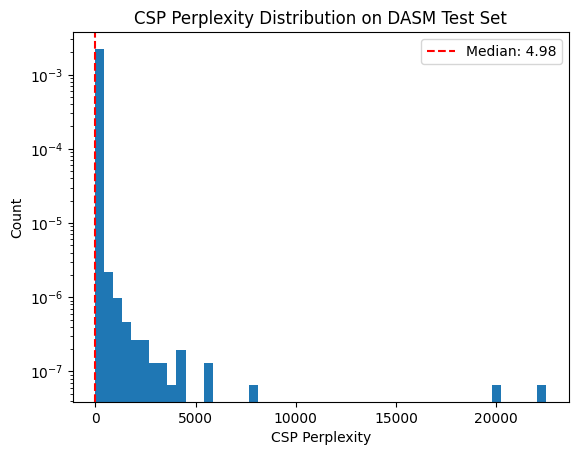

In [8]:
# histplot the perplexities
plt.hist(perplexities, bins=50, density=True)

# add xline for median of perplexities and write value
median = np.median(perplexities)
print(f"Median perplexity: {median:.2f}")
plt.axvline(median, color='r', linestyle='--', label=f'Median: {median:.2f}')
plt.legend()

plt.ylabel('Count')
plt.xlabel('CSP Perplexity')
plt.yscale('log')
plt.title("CSP Perplexity Distribution on DASM Test Set")
plt.show()

In [9]:
# save perplexities to file
perplexities = np.array(perplexities)
pcp_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed/rodriguez-igh.csv")
assert pcp_df.shape[0] == perplexities.shape[0], "Number of perplexities should match number of sequences"
pcp_df["peint_csp_perplexity"] = perplexities
pcp_df['peint_csp_perplexity'].describe()
pcp_df.to_csv("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed/rodriguez-igh.csv", index=False)

In [47]:
# Infer ppl for the koenig binding dataset
df = pd.read_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_g6_Kd.csv")

heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))
df['mut'] = df['heavy_mut'] + df['light_mut']
df.set_index('mut', inplace=True)

print(df.shape)
df.head()

120 108 228
(4275, 6)


,heavy,light,fitness,branch_length,heavy_mut,light_mut
mut,,,,,,
V1A,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,3.620218,0.006929,V1A,
V1C,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.142127,0.010411,V1C,
V1D,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.378990,0.006929,V1D,
V1E,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.578943,0.003458,V1E,
V1F,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.806596,0.006926,V1F,


In [52]:
heavy_transitions = [ f"{heavy_wt.strip()} {row.heavy.strip()} {row.branch_length}" for _, row in df.iterrows() ]
light_transitions = [ f"{light_wt.strip()} {row.light.strip()} {row.branch_length}" for _, row in df.iterrows() ]

In [53]:
dataloader = dataloader_from_transitions(heavy_transitions, batch_size=32, chain_id_offset=1)
# heavy_lls = infer_log_likelihoods(dataloader, module)
heavy_logits = infer_logits(dataloader, module)
print(heavy_logits.shape)  # (N, L, vocab_size)

Inference: 100%|█████████████████████████████████████████████████████████████████████| 134/134 [00:14<00:00,  9.38it/s]


(4275, 120, 20)


In [54]:
dataloader = dataloader_from_transitions(light_transitions, batch_size=32, chain_id_offset=2)
# light_lls = infer_log_likelihoods(dataloader, module)
light_logits = infer_logits(dataloader, module)
print(light_logits.shape)  # (N, L, vocab_size)

Inference: 100%|█████████████████████████████████████████████████████████████████████| 134/134 [00:14<00:00,  9.30it/s]


(4275, 108, 20)


In [55]:
# merge the heavy and light logits in the sequence dimension with a pad in between
N = heavy_logits.shape[0]
L_heavy = heavy_logits.shape[1]
L_light = light_logits.shape[1]
vocab_size = heavy_logits.shape[2]
pad_logits = np.zeros((N, 1, vocab_size))  # (N, 1, vocab_size)
merged_logits = np.concatenate([heavy_logits, pad_logits, light_logits], axis=1)  # (N, L_heavy + 1 + L_light, vocab_size)
print(merged_logits.shape)  # (N, L_heavy + 1 + L_light, vocab_size)

(4275, 229, 20)


In [56]:
# save the logits to a file that is easy to load with numpy
np.save("/scratch/users/stephen.lu/projects/protevo/data/flab/koenig2017_g6_per_chain_logits.npy", merged_logits)

In [27]:
df['heavy_ll'] = heavy_lls
df['light_ll'] = light_lls
df['heavy_plus_light_ll'] = df['heavy_ll'] + df['light_ll']
df['heavy_plus_light_ppl'] = np.exp(-df['heavy_plus_light_ll'] / (len(heavy_wt) + len(light_wt)))

In [59]:
heavy_transitions = []
light_transitions = []
all_transitions = []
heavy_muts = []
light_muts = []

for i, row in df.iterrows():
    if row['heavy'] != heavy_wt:
        heavy_muts.append(row['heavy_mut'])
        heavy_transitions.append(f"{heavy_wt.strip()}.{light_wt.strip()} {row.heavy.strip()}.{light_wt.strip()} {row.branch_length}")
    if row['light'] != light_wt:
        light_muts.append(row['light_mut'])
        light_transitions.append(f"{heavy_wt.strip()}.{light_wt.strip()} {heavy_wt.strip()}.{row.light.strip()} {row.branch_length}")
    all_transitions.append(
        f"{heavy_wt.strip()}.{light_wt.strip()} {row.heavy.strip()}.{row.light.strip()} {row.branch_length}"
    )

In [ ]:
heavy_fw_dataloader = dataloader_from_transitions(heavy_transitions, batch_size=32, permute_method=None)
light_fw_dataloader = dataloader_from_transitions(light_transitions, batch_size=32, permute_method=None)
heavy_bw_dataloader = dataloader_from_transitions(heavy_transitions, batch_size=32, permute_method="reverse")
light_bw_dataloader = dataloader_from_transitions(light_transitions, batch_size=32, permute_method="reverse")

heavy_fw_lls = infer_log_likelihoods(heavy_fw_dataloader, module)
light_fw_lls = infer_log_likelihoods(light_fw_dataloader, module)

# heavy_bw_lls = [0] * len(heavy_fw_lls)
# light_bw_lls = [0] * len(light_fw_lls)
heavy_bw_lls = infer_log_likelihoods(heavy_bw_dataloader, module)
light_bw_lls = infer_log_likelihoods(light_bw_dataloader, module)

Inference: 100%|███████████████████████████████████████████████████████████████████████| 63/63 [00:12<00:00,  5.23it/s]


(2261, 229, 20) (2014, 229, 20)


In [60]:
joint_dataloader = dataloader_from_transitions(all_transitions, batch_size=32, permute_method=None)
joint_logits = infer_logits(joint_dataloader, module)
print(joint_logits.shape)  # (N, L_heavy + 1 + L_light, vocab_size)

Inference: 100%|█████████████████████████████████████████████████████████████████████| 134/134 [00:25<00:00,  5.20it/s]

(4275, 229, 20)


In [61]:
# save logits to file
np.save("/scratch/users/stephen.lu/projects/protevo/data/flab/koenig2017_g6_joint_logits.npy", joint_logits)

In [30]:
for mut, fll, bll in zip(heavy_muts, heavy_fw_lls, heavy_bw_lls):
    ll = fll + bll
    df.at[mut, 'joint_ll'] = ll
    df.at[mut, 'joint_ppl'] = np.exp(-ll / (len(heavy_wt) + len(light_wt)))

for mut, fll, bll in zip(light_muts, light_fw_lls, light_bw_lls):
    ll = fll + bll
    df.at[mut, 'joint_ll'] = ll
    df.at[mut, 'joint_ppl'] = np.exp(-ll / (len(heavy_wt) + len(light_wt)))

In [31]:
df

,heavy,light,fitness,branch_length,heavy_mut,light_mut,heavy_ll,light_ll,heavy_plus_light_ll,heavy_plus_light_ppl,joint_ll,joint_ppl
mut,,,,,,,,,,,,
V1A,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,3.620218,0.006929,V1A,,-7.028034,-0.683642,-7.711677,1.034402,-18.263643,1.083399
V1C,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.142127,0.010411,V1C,,-14.188503,-0.872175,-15.060678,1.068286,-34.407154,1.162890
V1D,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.378990,0.006929,V1D,,-12.353426,-4.547121,-16.900547,1.076942,-27.379738,1.127594
V1E,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.578943,0.003458,V1E,,-7.697164,-0.521666,-8.218830,1.036705,-18.250916,1.083339
V1F,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.806596,0.006926,V1F,,-10.321194,-1.023805,-11.344999,1.051018,-25.990143,1.120743
...,...,...,...,...,...,...,...,...,...,...,...,...
K106S,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.034414,0.006943,,K106S,-1.020775,-10.096194,-11.116970,1.049967,-25.622438,1.118937
K106T,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.456846,0.006943,,K106T,-0.997675,-7.345248,-8.342923,1.037269,-19.346413,1.088557
K106V,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.565224,0.006937,,K106V,-1.056239,-10.398456,-11.454695,1.051523,-27.417896,1.127783


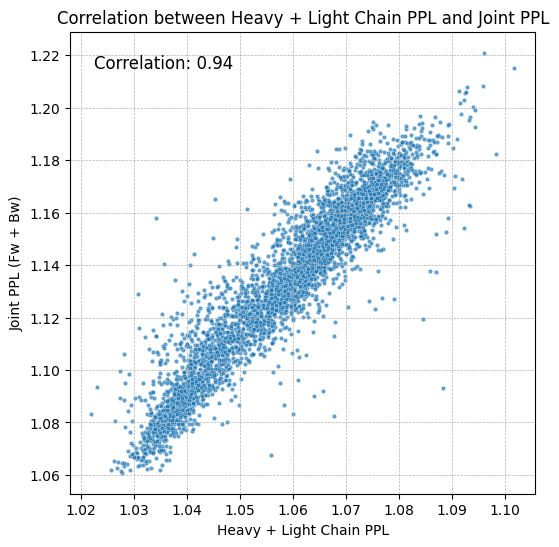

In [32]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='heavy_plus_light_ppl', y='joint_ppl', alpha=0.7, s=10, legend=False)
plt.xlabel('Heavy + Light Chain PPL')
plt.ylabel('Joint PPL (Fw + Bw)')
plt.title('Correlation between Heavy + Light Chain PPL and Joint PPL')
plt.grid(True, which="both", ls="--", linewidth=0.5)

corr = df[['heavy_plus_light_ppl', 'joint_ppl']].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top')

from matplotlib.ticker import ScalarFormatter

plt.show()


In [33]:
df.to_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_ppl_peint_dasm_fitted_t.csv", index=False)